In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Read the CSV file 20th_century.csv
df = pd.read_csv('20th_century_timeline.csv')

In [25]:
#All events that are related to war
df_war = df[df['Event Description'].str.contains(' war ', case=False)]
print(df_war)

#save the data to a new csv file
df_war.to_csv('war_events.csv', index=False)

     Date                                  Event Description
10   1902           Second Boer War ends in British victory.
27   1905   The Russo-Japanese War ends in Japanese victory.
69   1911  The Italo-Turkish war which led to the capture...
82   1912                       The First Balkan War begins.
93   1914  Gavrilo Princip assassinates Archduke Franz Fe...
..    ...                                                ...
921  1997                 The First Liberian Civil War ends.
933  1998                       The Second Congo War begins.
944  1999              The Second Liberian Civil War begins.
947  1999  The end of the Kosovo War ends the Yugoslav Wars.
949  1999                     The Second Chechen War begins.

[80 rows x 2 columns]


/var/folders/nd/vshpv27n41q6rxlmgnb5lq7w0000gn/T/ipykernel_27093/3422269256.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_war['Date'] = df_war['Date'].astype(int)
/var/folders/nd/vshpv27n41q6rxlmgnb5lq7w0000gn/T/ipykernel_27093/3422269256.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_war['Decade'] = (df_war['Date'] // 10) * 10


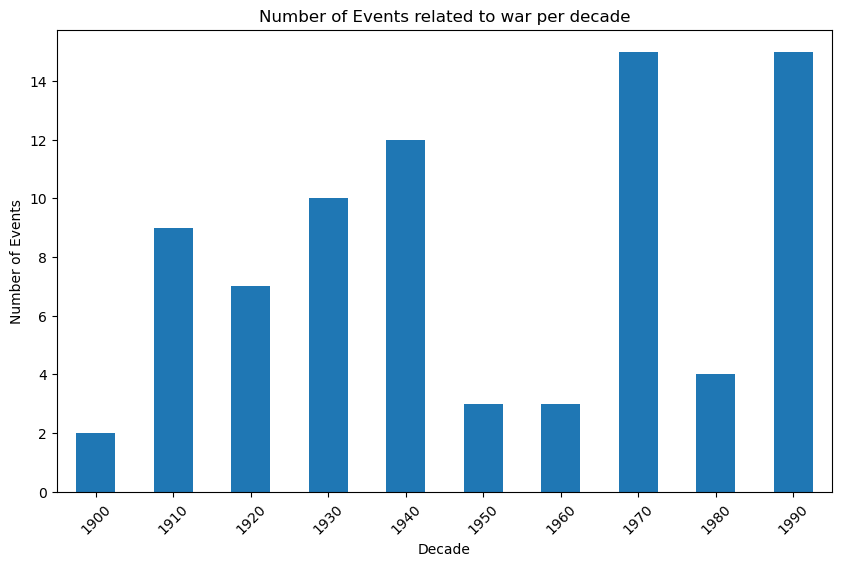

In [23]:
#Plot the number of war per decade
# Extract the year from the 'Year' column and convert it to an integer
df_war['Date'] = df_war['Date'].astype(int)

# Create a new column for the decade
df_war['Decade'] = (df_war['Date'] // 10) * 10

# Group the data by decade and count the number of events
decade_counts = df_war.groupby('Decade').size()

# Plot the data
plt.figure(figsize=(10, 6))
decade_counts.plot(kind='bar')
plt.xlabel('Decade')
plt.ylabel('Number of Events')
plt.title('Number of Events related to war per decade')
plt.xticks(rotation=45)
plt.show()

In [33]:
# Function country_to_continent from https://stackoverflow.com/questions/55910004/get-continent-name-from-country-using-pycountry
# Function find_countries from https://fastdatascience.com/natural-language-processing/country-named-entity-recognition/
import pycountry_convert as pc
import pycountry
from country_named_entity_recognition import find_countries

def country_to_continent(country_name): 
    try:
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        country_continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        country_continent_name = pc.convert_continent_code_to_continent_name(country_continent_code)
        return country_continent_name
    except Exception as e:
        print(f"Error converting country to continent: {country_name}, {e}")
        return None

# Iterate over the rows and create a new column 'Continent' that contains the continent of the country
for index, row in df_war.iterrows():
    countries = find_countries(row['Event Description'])
    country_names = [country[0].name for country in countries]  # Extract the country names

    continents = []
    for country in country_names:
        continent = country_to_continent(country)
        if continent:
            continents.append(continent)
    
    if continents:
        df_war.loc[index, 'Continent'] = continents[0]
    else:
        df_war.loc[index, 'Continent'] = 'Unknown'

# Save the data to a new CSV file
df_war.to_csv('war_events_continent.csv', index=False)
